## Logistic Regression

Miranda Rasmussen <br>
11/08/2025<br>
IMT 574: Data Science II: Machine Learning<br>
Instructor: Sophin Liu

### Question
**Can we classify a user as belonging to a video-based or text-based platform group based on their mental health and lifestyle metrics?**

In [1]:
#PackagesNeeded
#InitialCode
import numpy as np
import pandas as pd
import os, glob, textwrap

#Visuals
import matplotlib.pyplot as plt
import seaborn as sns

#Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

In [2]:
import os
import kagglehub
path = kagglehub.dataset_download("prince7489/mental-health-and-social-media-balance-dataset")
df = pd.read_csv(os.path.join(path, 'Mental_Health_and_Social_Media_Balance_Dataset.csv'))

/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#Define platform groups
video_based = ["YouTube", "TikTok", "Instagram", "Snapchat"]
text_based  = ["Facebook", "X (Twitter)", "LinkedIn", "WhatsApp", "Reddit"]

def map_platform_group(platform):
    if platform in video_based:
        return 1  # video-based
    elif platform in text_based:
        return 0  # text-based
    else:
        return np.nan  # unknown / not used

df["Platform_Group"] = df["Social_Media_Platform"].apply(map_platform_group)

#Drop rows we couldn't classify into video/text
df_clean = df.dropna(subset=["Platform_Group"]).copy()

df_clean["Platform_Group"] = df_clean["Platform_Group"].astype(int)

df_clean["Platform_Group"].value_counts()

Platform_Group
0    256
1    244
Name: count, dtype: int64

In [4]:
#Features: mental health + lifestyle metrics
feature_cols = [
    "Daily_Screen_Time(hrs)",
    "Sleep_Quality(1-10)",
    "Stress_Level(1-10)",
    "Days_Without_Social_Media",
    "Exercise_Frequency(week)",
    "Happiness_Index(1-10)"
]

X = df_clean[feature_cols]
y = df_clean["Platform_Group"]

#Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((400, 6), (100, 6))

In [5]:
#Build Logistic Regression Pipeline
log_reg_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",  
            random_state=42
        ))
    ]
)

#Fit
log_reg_pipeline.fit(X_train, y_train)

/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


,steps,"[('scaler', ...), ('logreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [6]:
#Predictions
y_pred = log_reg_pipeline.predict(X_test)
y_proba = log_reg_pipeline.predict_proba(X_test)[:, 1]  

#Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("Accuracy:  " + str(round(accuracy, 3)))
print("Precision: " + str(round(precision, 3)))
print("Recall:    " + str(round(recall, 3)))
print("F1-score:  " + str(round(f1, 3)))
print("ROC-AUC:   " + str(round(roc_auc, 3)))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Text-based", "Video-based"]))

Accuracy:  0.57
Precision: 0.568
Recall:    0.51
F1-score:  0.538
ROC-AUC:   0.597

Classification Report:

              precision    recall  f1-score   support

  Text-based       0.57      0.63      0.60        51
 Video-based       0.57      0.51      0.54        49

    accuracy                           0.57       100
   macro avg       0.57      0.57      0.57       100
weighted avg       0.57      0.57      0.57       100



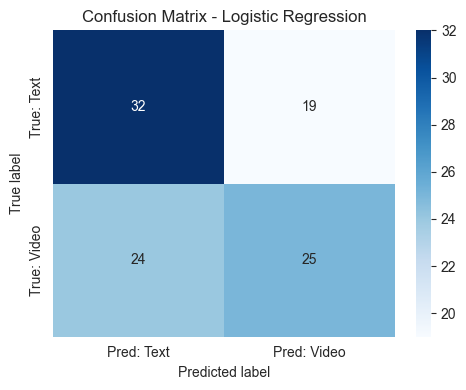

In [7]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: Text", "Pred: Video"],
            yticklabels=["True: Text", "True: Video"])
plt.title("Confusion Matrix - Logistic Regression")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

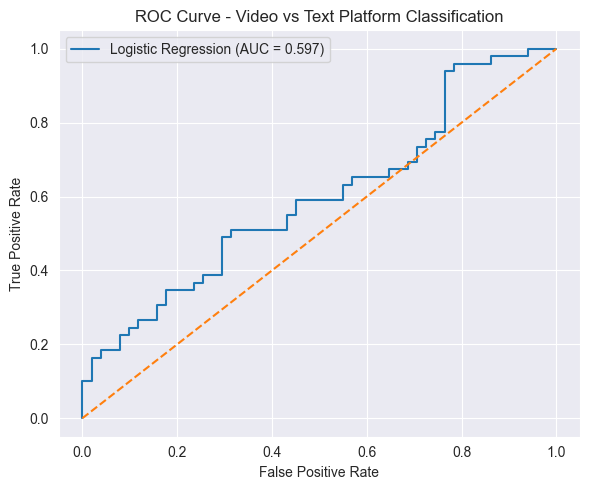

In [8]:
#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Video vs Text Platform Classification")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
#Get coefficients back to original feature space
logreg = log_reg_pipeline.named_steps["logreg"]
scaler = log_reg_pipeline.named_steps["scaler"]

coef = logreg.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": coef
}).sort_values("coefficient", ascending=False)

coef_df

,feature,coefficient
4,Exercise_Frequency(week),0.232179
1,Sleep_Quality(1-10),0.120937
0,Daily_Screen_Time(hrs),0.071209
3,Days_Without_Social_Media,0.016903
2,Stress_Level(1-10),0.013557
5,Happiness_Index(1-10),-0.219452


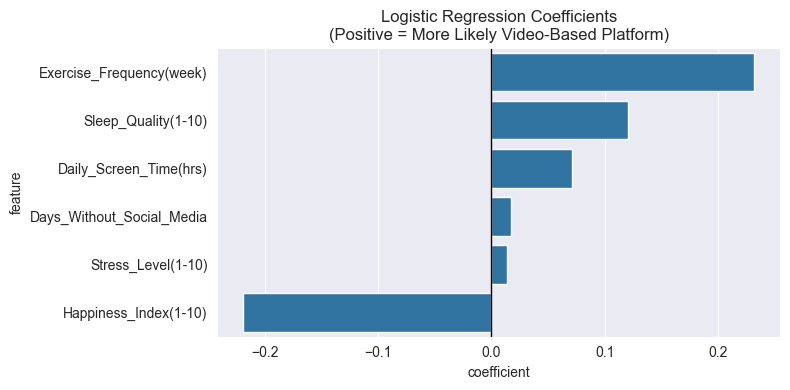

In [10]:
plt.figure(figsize=(8,4))
sns.barplot(data=coef_df, x="coefficient", y="feature")
plt.axvline(0, color="black", linewidth=1)
plt.title("Logistic Regression Coefficients\n(Positive = More Likely Video-Based Platform)")
plt.tight_layout()
plt.show()

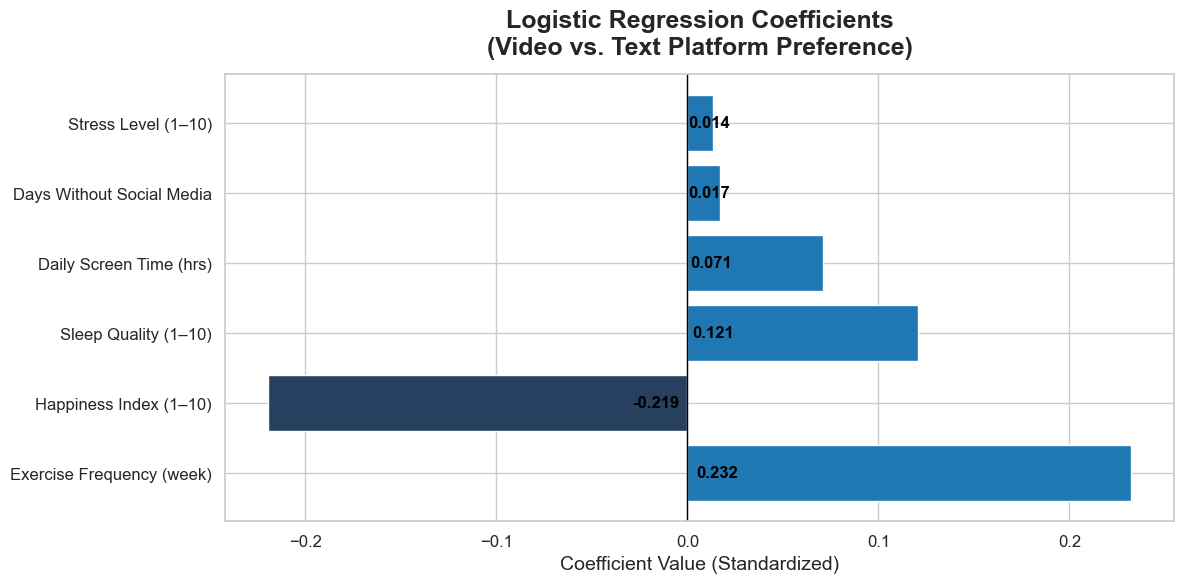

In [11]:
#Bar graph of coeffs
#Data
features = [
    "Exercise Frequency (week)",
    "Sleep Quality (1–10)",
    "Daily Screen Time (hrs)",
    "Days Without Social Media",
    "Stress Level (1–10)",
    "Happiness Index (1–10)"
]

coeffs = [0.232179, 0.120937, 0.071209, 0.016903, 0.013557, -0.219452]

df = pd.DataFrame({"Feature": features, "Coefficient": coeffs})

#Sort by absolute value for ordering
df = df.reindex(df.Coefficient.abs().sort_values(ascending=False).index)

#Use clean white-grid style
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

#Color mapping
colors = df["Coefficient"].apply(lambda x: "#1f77b4" if x > 0 else "#274060")

#Create horizontal bar plot
bars = plt.barh(df["Feature"], df["Coefficient"], color=colors)

#Zero line
plt.axvline(0, color="black", linewidth=1)

#Title and axis labels
plt.title("Logistic Regression Coefficients\n(Video vs. Text Platform Preference)",
          fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Coefficient Value (Standardized)", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

#Add in-bar labels
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    if width > 0:
        # Positive bars → text on left inside the bar
        plt.text(width * 0.02, y, f"{width:.3f}",
                 va='center', ha='left', fontsize=12, color="black", fontweight='bold')
    else:
        # Negative bars → text on right inside the bar
        plt.text(width * 0.02, y, f"{width:.3f}",
                 va='center', ha='right', fontsize=12, color="black", fontweight='bold')

plt.tight_layout()

plt.show()


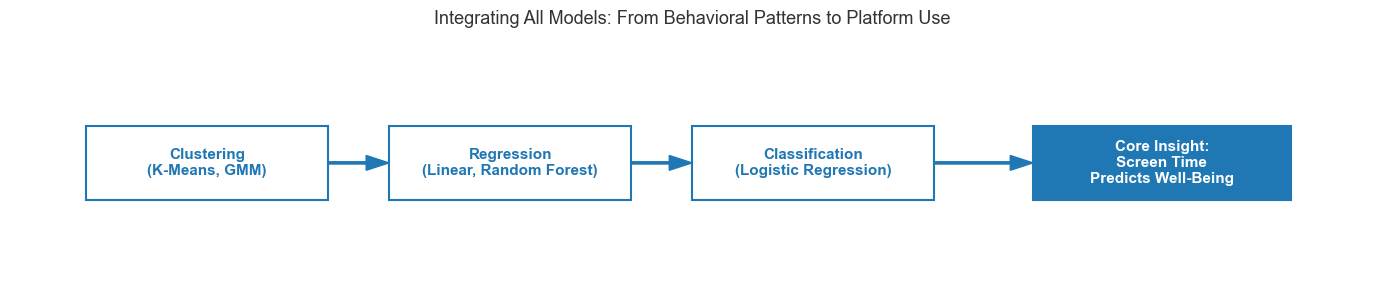

In [12]:
#Visual for conslusion slide.
from matplotlib.patches import FancyArrow, Rectangle

fig, ax = plt.subplots(figsize=(14, 3))

ax.set_xlim(0, 18)
ax.set_ylim(0, 3)
ax.axis('off')

def add_box(x, text, width=3.2, edge='#1f77b4', face='white', weight='bold', color='#1f77b4'):
    rect = Rectangle((x, 1), width, 1, linewidth=1.5,
                     edgecolor=edge, facecolor=face)
    ax.add_patch(rect)
    ax.text(
        x + width/2,
        1.5,
        text,
        ha='center',
        va='center',
        fontsize=11,
        color=color,
        fontweight=weight,
        wrap=True,
    )

def add_arrow(x1, x2, y=1.5, color='#1f77b4'):
    ax.add_patch(
        FancyArrow(
            x1, y,
            x2 - x1, 0,
            width=0.03,
            head_width=0.2,
            color=color,
            length_includes_head=True,
        )
    )

box_width = 3.2


x_cluster = 1.0
x_reg     = 5.0
x_class   = 9.0
x_core    = 13.5  

add_box(x_cluster, "Clustering\n(K-Means, GMM)", width=box_width)
add_box(x_reg, "Regression\n(Linear, Random Forest)", width=box_width)
add_box(x_class, "Classification\n(Logistic Regression)", width=box_width)

#Core insight box: filled blue with white text
add_box(
    x_core,
    "Core Insight:\nScreen Time\nPredicts Well-Being",
    width=3.4,
    edge='#1f77b4',
    face='#1f77b4',
    weight='bold',
    color='white'
)

add_arrow(x_cluster + box_width, x_reg, y=1.5)
add_arrow(x_reg + box_width, x_class, y=1.5)
add_arrow(x_class + box_width, x_core, y=1.5)

plt.title("Integrating All Models: From Behavioral Patterns to Platform Use",
          fontsize=13, color='#333333', pad=20)

plt.tight_layout()
plt.show()
